# PYTHON 5 - LESSON 6
## Machine Learning - Sentiment Analysis (Part 2)

Date: 05 June 2024

#### Summary

Today was a continuation of Lesson 5, where we learned how to train a machine learning model to recognise the sentiment of sentences as either `happy`, `sad`, `angry`, `sarcastic`, `fearful, or `surprised`. We used the website Machine Learning for Kids for that (https://machinelearningforkids.co.uk/).

If you need a little recap of how to train your model on ML for Kids, check out this video: https://drive.google.com/file/d/1hFpfJ0PJmNmsbCY9Q28Auwbq5e8IVMix/view?usp=share_link

When running the Python code below, make sure you replace the `key` in:

```
# Model 1 (5 examples)
key1 = "8176a890-2757-11ef-832e-2136c40f26ea97269a44-4220-47e8-bffd-20181e5834cf"

# Model 2 (50 examples)
key2 = "85c9bff0-2760-11ef-982e-99475827aa2583ca2fa4-3544-4da0-b313-b28470a37c5d"
```

with the API key of your own model. If you don't know where to find it, check out the instructions in this PDF: https://drive.google.com/file/d/1dscpJA733PYMHmXf5ueuNHRm4RaNlEB4/view?usp=share_link

Today we focused on improving the performance of our sentiment model by training it on more examples. We also calculated and plotted a `confusion matrix` of our results, to visualise which sentiments the model predicted correctly, and which sentiments it struggled with.

In [ ]:
# Import libraries
import requests
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# https://machinelearningforkids.co.uk/
# This function will pass your text to the machine learning model
# and return the top result with the highest confidence
def classify(text, key):
    url = "https://machinelearningforkids.co.uk/api/scratch/"+ key + "/classify"

    response = requests.get(url, params={ "data" : text })

    if response.ok:
        responseData = response.json()
        topMatch = responseData[0]
        return topMatch
    else:
        response.raise_for_status()


# This function will predict the sentiment label of many examples
# Examples are provided in a dataframe (data)
# The function returns a list of predicted labels
def predict(data, key):
  pred_labels = []
  for text in data['example']:
    result = classify(text, key)
    label = result['class_name']
    pred_labels.append(label)

  return pred_labels


# This function will plot a confusion matrix
def plot_cm(true_labels, pred_labels):
  labels = np.unique(true_labels)
  cm = confusion_matrix(true_labels, pred_labels, labels=labels)

  plt.figure(figsize=(10,7))

  sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)

  plt.xlabel("Predicted")
  plt.ylabel("True")

### Test model on many examples (test set)

In [ ]:
# Path to your CSV file
file_path = "/content/sentiment_test_examples.csv"
data = pd.read_csv(file_path)
data.head()

,example,class_name
0,"Just got a free upgrade on my flight, feeling ...",happy
1,"The garden party was a hit, everyone left smil...",happy
2,What a fantastic view from this new restaurant!,happy
3,"My team just won the championship, so ecstatic!",happy
4,Surprise visit from my best friend made my day!,happy


In [ ]:
# Filter sentiments that are in the model (optional)
sentiments = ["happy", "sad", "angry", "sarcastic", "fearful", "surprised"]
data = data.loc[data['class_name'].isin(sentiments),]
data['class_name'].value_counts()

class_name
happy        10
sad          10
angry        10
sarcastic    10
fearful      10
surprised    10
Name: count, dtype: int64

### Evaluate performance of different models using the 'accuracy' metric and the 'confusion matrix'

0.5333333333333333


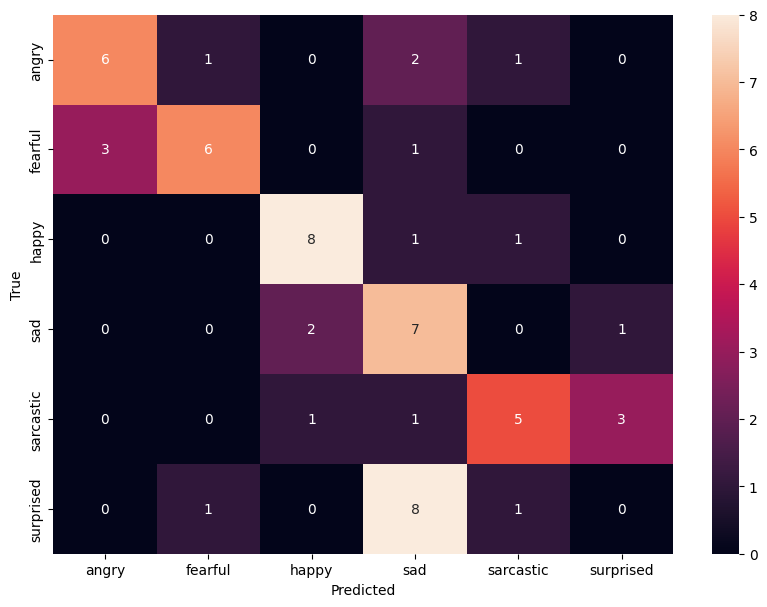

In [ ]:
# Model 1 (5 examples)
key1 = "8176a890-2757-11ef-832e-2136c40f26ea97269a44-4220-47e8-bffd-20181e5834cf"

# predicted labels
pred_labels = predict(data, key1)

# true labels
true_labels = data['class_name'].tolist()

# calculate accuracy
accuracy = accuracy_score(true_labels, pred_labels)
print(accuracy)

# plot confusion matrix
plot_cm(true_labels, pred_labels)

0.7166666666666667


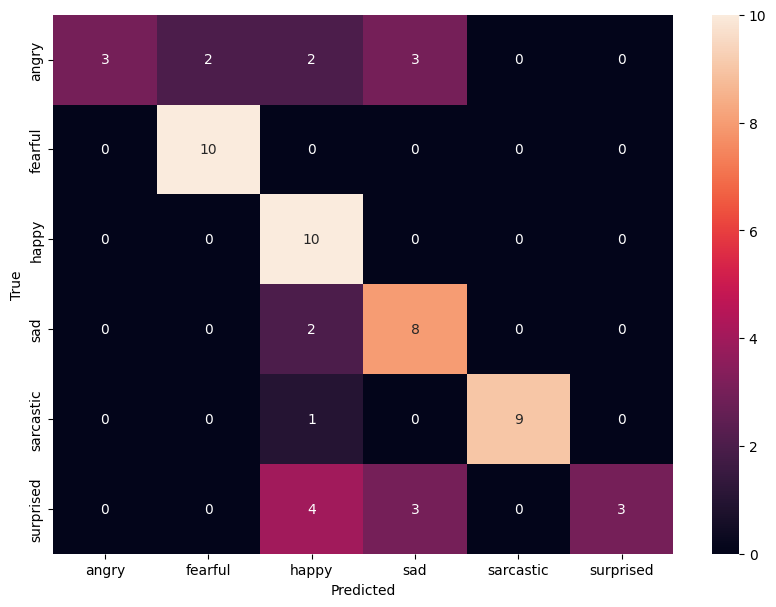

In [ ]:
# Model 2 (50 examples)
key2 = "85c9bff0-2760-11ef-982e-99475827aa2583ca2fa4-3544-4da0-b313-b28470a37c5d"

# predicted labels
pred_labels = predict(data, key2)

# true labels
true_labels = data['class_name'].tolist()

# calculate accuracy
accuracy = accuracy_score(true_labels, pred_labels)
print(accuracy)

# plot confusion matrix
plot_cm(true_labels, pred_labels)

Which model performs better? Model 1 (5 examples) or Model 2 (50 examples)?